In [1]:
pip install mlflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Petar\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [3]:
!pip install timm

   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 2.6/2.6 MB 18.6 MB/s  0:00:00



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Petar\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [48]:
import pandas as pd
import torch
import os
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.nn as nn
import mlflow
from tqdm import tqdm
import numpy as np
from sklearn.metrics import roc_auc_score
import timm
from peft import LoraConfig, get_peft_model

# Fine-Tuning ConvNeXt-V2 for Chest X-Ray Diagnosis

This project focuses on the multi-label classification of 14 distinct lung pathologies using the **NIH ChestX-ray14** dataset. This implementation utilizes ConvNeXt-V2 which is a state-of-the-art convolutional architecture that integrates the design principles and self-supervised training logic - Fully Convolutional Masked Autoencoder - FCMAE of Vision Transformers, but retains the computational efficiency, low VRAM footprint, and native compatibility of CNNs. /
Multi-label classification which means that images can have multiple pathologies simultaneously.
There are 14 classes:
* Infiltration
* Effusion
* Atelectasis
* Nodule
* Mass
* Pneumothorax
* Consolidation 
* Pleural_Thickening   
* Cardiomegaly          
* Emphysema   
* Edema  
* Fibrosis    
* Pneumonia  
* Hernia

In [5]:
data_entry = pd.read_csv("Data_Entry_2017.csv")

In [6]:
data_entry.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,058Y,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,058Y,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,058Y,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,081Y,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,081Y,F,PA,2582,2991,0.143,0.143,NaN


In [7]:
data_entry["Finding Labels"].str.split('|').explode().unique()

array(['Cardiomegaly', 'Emphysema', 'Effusion', 'No Finding', 'Hernia',
       'Infiltration', 'Mass', 'Nodule', 'Atelectasis', 'Pneumothorax',
       'Pleural_Thickening', 'Pneumonia', 'Fibrosis', 'Edema',
       'Consolidation'], dtype=object)

In [8]:
unique_labels = data_entry["Finding Labels"].str.split('|').explode().unique()

In [9]:
diseases = [l for l in unique_labels if l != 'No Finding']

In [10]:
len(diseases)

14

In [11]:
#encoding labels
for label in diseases:
    data_entry[label] = data_entry['Finding Labels'].str.contains(label, regex = False).astype(int)

In [12]:
count_classes = data_entry[diseases].sum().sort_values(ascending = False)

In [13]:
(count_classes / len(data_entry) * 100).sort_values(ascending = False)

Infiltration          17.722083
Effusion              11.868534
Atelectasis           10.288084
Nodule                 5.639493
Mass                   5.124866
Pneumothorax           4.725294
Consolidation          4.162504
Pleural_Thickening     3.019087
Cardiomegaly           2.472351
Emphysema              2.244024
Edema                  2.054049
Fibrosis               1.503746
Pneumonia              1.206743
Hernia                 0.202462
dtype: float64

In [14]:
(((data_entry['Finding Labels'] == 'No Finding').sum()) /  len(data_entry)) * 100

np.float64(53.88155547627542)

In [15]:
healthy_patients = data_entry[data_entry['Finding Labels'] == 'No Finding']

In [16]:
healthy_patients.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,Infiltration,Mass,Nodule,Atelectasis,Pneumothorax,Pleural_Thickening,Pneumonia,Fibrosis,Edema,Consolidation
3,00000002_000.png,No Finding,0,2,081Y,M,PA,2500,2048,0.171,...,0,0,0,0,0,0,0,0,0,0
13,00000005_000.png,No Finding,0,5,069Y,F,PA,2048,2500,0.168,...,0,0,0,0,0,0,0,0,0,0
14,00000005_001.png,No Finding,1,5,069Y,F,AP,2500,2048,0.168,...,0,0,0,0,0,0,0,0,0,0
15,00000005_002.png,No Finding,2,5,069Y,F,AP,2500,2048,0.168,...,0,0,0,0,0,0,0,0,0,0
16,00000005_003.png,No Finding,3,5,069Y,F,PA,2992,2991,0.143,...,0,0,0,0,0,0,0,0,0,0


In [17]:
print(data_entry[data_entry['Finding Labels'].str.contains('|', regex=False)]['Finding Labels'].head(10))

1                                Cardiomegaly|Emphysema
2                                 Cardiomegaly|Effusion
7                                   Hernia|Infiltration
12                                          Mass|Nodule
20                                Effusion|Infiltration
37                                        Effusion|Mass
39                               Emphysema|Pneumothorax
40                               Emphysema|Pneumothorax
42         Effusion|Emphysema|Infiltration|Pneumothorax
43    Emphysema|Infiltration|Pleural_Thickening|Pneu...
Name: Finding Labels, dtype: object


### Data stratification

In [18]:
unique_ids = torch.tensor(data_entry["Patient ID"].unique())

In [19]:
#guarantee reproducibility
torch.manual_seed(42)

In [20]:
shuffled_indices = torch.randperm(len(unique_ids))

In [21]:
unique_ids = unique_ids[shuffled_indices].tolist()

In [22]:
split_train = int(len(unique_ids) * 0.8)
split_val = int(len(unique_ids) * 0.9)

In [23]:
train_ids = unique_ids[:split_train]
val_ids = unique_ids[split_train:split_val]
test_ids = unique_ids[split_val:]

In [24]:
train = data_entry[data_entry["Patient ID"].isin(train_ids)].sample(frac = 1, random_state = 42).reset_index(drop = True)
val = data_entry[data_entry["Patient ID"].isin(val_ids)].sample(frac = 1, random_state = 42).reset_index(drop = True)
test = data_entry[data_entry["Patient ID"].isin(test_ids)].sample(frac = 1, random_state = 42).reset_index(drop = True)

In [25]:
len(train), len(val), len(test)

(89794, 10644, 11682)

### Image preprocessing

Initialize standard PyTorch transformations for data preprocessing and normalization. Since the chest X-ray images are pre-resized to 224x224 pixels, the pipeline converts the images into numerical tensors and applies standard normalization using specific channel mean and standard deviation values. This calibration ensures that the input pixel distributions match the expected format required by the pretrained ConvNeXt-V2 backbone layers.

In [26]:
#data augmentation
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale = (0.8, 1.0)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees = 0, translate = (0.05, 0.05))
])

In [27]:
normalize_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

In [28]:
#custom dataset for loading images and multi-label tags
class ChestXrayDataset(Dataset):
    def __init__(self, dataset, img_dir, diseases, transform = None):
        self.dataset = dataset
        self.img_dir = img_dir
        self.diseases = diseases
        self.transform = transform #for augmentation

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img_name = self.dataset.iloc[idx]['Image Index']
        img_path = os.path.join(self.img_dir, img_name)
    
        image = Image.open(img_path).convert('RGB')
        if self.transform is not None: 
            image = self.transform(image)



        pixel_values = normalize_transform(image)
    
        labels_list = self.dataset.iloc[idx][self.diseases].values.astype('float32')
        labels_tensor = torch.tensor(labels_list, dtype=torch.float32)
    
        return {
            'pixel_values': pixel_values,
            'labels': labels_tensor
        }

In [29]:
train_dataset = ChestXrayDataset(dataset = train, img_dir = 'images-224/images-224', diseases = diseases, transform = train_transforms)

In [30]:
val_dataset = ChestXrayDataset(dataset = val, img_dir = 'images-224/images-224', diseases = diseases, transform = None)

In [31]:
test_dataset = ChestXrayDataset(dataset = test, img_dir = 'images-224/images-224', diseases = diseases, transform = None)

In [32]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True, num_workers = 0, pin_memory = True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = False, num_workers = 0, pin_memory = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False, num_workers = 0, pin_memory = True)

In [33]:
sample_dataset = next(iter(train_loader))

In [34]:
sample_rows = train.head(4)

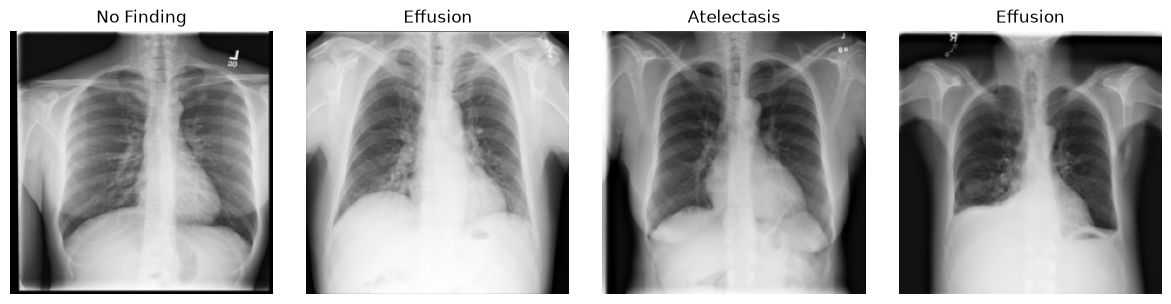

In [35]:
fig, axes = plt.subplots(1, 4, figsize = (12, 3))
for i, ax in enumerate(axes):
    img_name = sample_rows.iloc[i]['Image Index']
    img_path = os.path.join('images-224/images-224', img_name)
    raw_img = Image.open(img_path)
    
    ax.imshow(raw_img, cmap='gray')
    ax.set_title(sample_rows.iloc[i]['Finding Labels'])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [37]:
device

device(type='cuda')

### Class imbalance assessment

Calculate negative-to-positive ratio for each of the 14 pathologies to fix the problem with unbalanced 
* positive - diseases
* negative - healthy cases

In [38]:
positive_weights = []
for disease in diseases:
    positive = train[disease].sum()
    negative = len(train) - positive
    positive_weights.append(negative / (positive + 0.00001)) #add 0.00001 to prevent zero divide 

In [39]:
#We transform the list into a tensor because pytorch requires this format for calculation
weights_tensor = torch.tensor(positive_weights, dtype = torch.float32)

In [40]:
#apply sqrt scaling to the weights in order to minimize extremely high values
weights_tensor = torch.sqrt(weights_tensor)

In [41]:
print(weights_tensor)

tensor([ 6.2038,  6.6086,  2.7197, 21.5466,  2.1474,  4.3747,  4.1467,  2.9619,
         4.5065,  5.6991,  8.9384,  8.1806,  6.8796,  4.8089])


We observe a huge class imbalance across the 14 pathologies. We will apply these values in the loss function (BCEWithLogitsLoss) as positive weight (when there is а disease case). This ensures the model is penalized more heavily when it misses rare diseases.

## Load Base Model

In [42]:
#load the official base ConvNext Model
base_model = timm.create_model('convnextv2_base', pretrained = True, num_classes = 14)

model.safetensors: reconstructing file:   0%|          |  0.00B /  355MB            

model.safetensors: downloading bytes:           |  0.00B            

C:\Users\Petar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Petar\.cache\huggingface\hub\models--timm--convnextv2_base.fcmae_ft_in22k_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


### Low-Rank Adaptation Configuration

In [46]:
lora_config = LoraConfig(
    r = 16,
    lora_alpha = 32,
    target_modules = ["mlp.fc1", "mlp.fc2"], 
    lora_dropout = 0.1,
    bias = "none",
    modules_to_save = ["head.fc"]
)

In [49]:
model = get_peft_model(base_model, lora_config)

In [50]:
model.print_trainable_parameters()

trainable params: 2,902,030 || all params: 90,609,180 || trainable%: 3.2028


We freeze the big model and insert tiny trainable matrices using Hugging Face PEFT library.
* r = 16 (rank) id the size of our trainable layers
* lora_alpha = 32 is a scaling factor that balances the power between our new LoRA weights and the frozen base model
* lora_dropout is for preventing the model from overfitting
* ["mlp.fc1", "mlp.fc2"] - we place LoRA adapters inside the MLP layers of the ConvNeXt blocks. This updates how the model processes chest textures without breaking its fundamental vision
* ["head.fc"] - the original model was trained for 1000 everyday objects (dogs, cars). We completely replace the final layer with a new classification head for our 14 specific medical diseases


In [51]:
model.to(device)

PeftModel(
  (base_model): LoraModel(
    (model): ConvNeXt(
      (stem): Sequential(
        (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((128,), eps=1e-06, elementwise_affine=True)
      )
      (stages): Sequential(
        (0): ConvNeXtStage(
          (downsample): Identity()
          (blocks): Sequential(
            (0): ConvNeXtBlock(
              (conv_dw): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
              (norm): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
              (mlp): GlobalResponseNormMlp(
                (fc1): lora.Linear(
                  (base_layer): Linear(in_features=128, out_features=512, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=128, out_features=16, bias=False)
                  )
 

## ML flow integration

In [52]:
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

In [53]:
mlflow.set_tracking_uri("file:./mlruns_fine_tuning_convnext_chest_xray")

In [54]:
mlflow.set_experiment("Fine-Tuning ConvNeXt-V2 Chest X Ray")

2026/08/23 20:06:22 INFO mlflow.tracking.fluent: Experiment with name 'Fine-Tuning ConvNeXt-V2 Chest X Ray' does not exist. Creating a new experiment.


<Experiment: artifact_location=('file:C:/Users/Petar/Desktop/New folder/Deep '
 'learning/Project/mlruns_fine_tuning_convnext_chest_xray/758397728355982535'), creation_time=1787504782250, effective_trace_archival_retention=None, experiment_id='758397728355982535', last_update_time=1787504782250, lifecycle_stage='active', name='Fine-Tuning ConvNeXt-V2 Chest X Ray', tags={}, trace_location=None, workspace='default'>

In [55]:
model = model.to(device)

## Model training and optimization

In [56]:
def train_model(model, train_loader, val_loader, optimizer, epochs, run_name):
    criterion = nn.BCEWithLogitsLoss(pos_weight = weights_tensor.to(device))
    best_auc = 0.0

    with mlflow.start_run(run_name = run_name):
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("batch_size", train_loader.batch_size)
        mlflow.log_param("model_architecture", "ConvNeXt-V2-Base-LoRA")
        mlflow.log_param("loss_function", "BCEWithLogitsLoss")

        for epoch in range(epochs):
            print(f"\nEpoch {epoch + 1}/{epochs}")

            model.train()
            train_loss = 0.0
            all_train_labels = []
            all_train_outputs = []

            pbar = tqdm(train_loader, desc = f"Epoch {epoch + 1} - Training", leave = True)
            for batch in pbar:
                inputs = batch['pixel_values'].to(device)
                labels = batch['labels'].to(device).float()
                
                optimizer.zero_grad()
                
                outputs = model(inputs)
                if hasattr(outputs, "logits"):
                    outputs = outputs.logits
                    
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item() * inputs.size(0)
                all_train_labels.append(labels.cpu().numpy())
                all_train_outputs.append(torch.sigmoid(outputs).detach().cpu().numpy())
                pbar.set_postfix({'loss': f"{loss.item():.4f}"})

            epoch_train_loss = train_loss / len(train_loader.dataset)
            all_train_labels = np.vstack(all_train_labels)
            all_train_outputs = np.vstack(all_train_outputs)
            epoch_train_auc = roc_auc_score(all_train_labels, all_train_outputs, average = "macro")

            model.eval()
            val_loss = 0.0

            all_labels = []
            all_outputs = []

            with torch.no_grad():
                for batch in val_loader:
                    inputs = batch['pixel_values'].to(device)
                    labels = batch['labels'].to(device).float()
                    
                    outputs = model(inputs)
                    if hasattr(outputs, "logits"):
                        outputs = outputs.logits
                    
                    loss = criterion(outputs, labels)
                    val_loss += loss.item() * inputs.size(0)

                    all_labels.append(labels.cpu().numpy())
                    all_outputs.append(torch.sigmoid(outputs).detach().cpu().numpy())

            epoch_val_loss = val_loss / len(val_loader.dataset)
            all_labels = np.vstack(all_labels)
            all_outputs = np.vstack(all_outputs)

            epoch_val_auc = roc_auc_score(all_labels, all_outputs, average = "macro")

            print(f"Train Loss: {epoch_train_loss:.4f} | Train AUC: {epoch_train_auc:.4f} | Val Loss: {epoch_val_loss:.4f} | Val AUC-ROC: {epoch_val_auc:.4f}")

            mlflow.log_metric("train_loss", epoch_train_loss, step = epoch)
            mlflow.log_metric("val_loss", epoch_val_loss, step = epoch)
            mlflow.log_metric("val_auc_roc", epoch_val_auc, step = epoch)

            path = "./checkpoints_project"
            os.makedirs(path, exist_ok = True)

            if epoch_val_auc > best_auc:
                best_auc = epoch_val_auc
                print(f"New best model found with AUC: {best_auc:.4f}")

                checkpoint = {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_auc": best_auc
                }
                torch.save(checkpoint, os.path.join(path, "best_model.pt"))

        model.save_pretrained("./final_lora_weights")
        mlflow.log_artifacts("./final_lora_weights", artifact_path="final_convnextv2_lora_model")

In [57]:
trainable_params = [p for p in model.parameters() if p.requires_grad]

In [58]:
optimizer = torch.optim.AdamW(trainable_params, lr = 0.0001, weight_decay = 0.01)

In [59]:
train_model(
    model = model, 
    train_loader = train_loader, 
    val_loader = val_loader, 
    optimizer = optimizer, 
    epochs = 10, 
    run_name = "convnextv2_base_lora_run1"
)


Epoch 1/10


Epoch 1 - Training: 100%|██████████| 2807/2807 [15:24<00:00,  3.04it/s, loss=0.6464]


Train Loss: 0.4298 | Train AUC: 0.7630 | Val Loss: 0.3904 | Val AUC-ROC: 0.8153
New best model found with AUC: 0.8153

Epoch 2/10


Epoch 2 - Training: 100%|██████████| 2807/2807 [15:17<00:00,  3.06it/s, loss=0.3751]


Train Loss: 0.3898 | Train AUC: 0.8181 | Val Loss: 0.3775 | Val AUC-ROC: 0.8316
New best model found with AUC: 0.8316

Epoch 3/10


...

Train Loss: 0.3305 | Train AUC: 0.8807 | Val Loss: 0.3681 | Val AUC-ROC: 0.8429

Epoch 9/10


Epoch 9 - Training: 100%|██████████| 2807/2807 [15:18<00:00,  3.06it/s, loss=0.2185]


Train Loss: 0.3211 | Train AUC: 0.8889 | Val Loss: 0.3747 | Val AUC-ROC: 0.8382

Epoch 10/10


Epoch 10 - Training: 100%|██████████| 2807/2807 [15:20<00:00,  3.05it/s, loss=0.2065]


Train Loss: 0.3115 | Train AUC: 0.8970 | Val Loss: 0.3732 | Val AUC-ROC: 0.8387


The model hits a performance plateau at epoch 6 with a maximum macro AUC-ROC of 0.8436. After this point, the validation score stops improving and fluctuates around 0.838 - 0.843.
While the validation AUC remains stuck in a plateau, the train AUC continues to rise steadily from 0.8316 to 0.8970 at epoch 10. This diverging gap indicates that training past epoch 6 forces the LoRA layers to memorize training artifacts rather than learning general medical features. 
The plateau at Epoch 6 indicates that the selected low-rank configuration r=16 reached its maximum capacity.\
To overcome this capacity limitation, hyperparameter tuning will be required in the next phase.